# LLM-Project 
Develop a suitable LLM Model to analyze and explain logistics speed metrics across logistics providers, routes, and time periods, so that I can quickly surface delays, identify potential root causes, and communicate actionable insights to stakeholders without writing complex SQL for every new question. 

Model used: `deepseek-v4-flash`

## Dataset Cleaning

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from dotenv import load_dotenv
import os
from dotenv import load_dotenv
import matplotlib.dates as mdates
load_dotenv()

True

In [20]:
data = pd.read_csv('llm_test_dataset_20260610-170741.csv', parse_dates = ['dt'])
print(data.head())
print(data.dtypes)

          dt buyer_country    buyer_region seller_country   seller_region  \
0 2026-01-01            PH   Ilocos Region             PH   Ilocos Region   
1 2026-01-01            MY        Selangor             MY           Sabah   
2 2026-01-01            MY         Sarawak             MY           Sabah   
3 2026-01-01            ID  South Sulawesi             ID  South Sulawesi   
4 2026-01-01            TH    Nakhon Sawan             TH      Nonthaburi   

  logistics_provider  parcel_qty   sum_apt    sum_bwt  
0        2GO Express       11928  10414.72   15281.22  
1       Pos Malaysia       13785  11141.05  101129.85  
2                J&T       17612  13489.63   62568.18  
3            SiCepat       14106  11214.95   24505.87  
4      Kerry Express       25292  16841.12   59686.99  
dt                    datetime64[us]
buyer_country                    str
buyer_region                     str
seller_country                   str
seller_region                    str
logistics_provid

### Identifying missing values, duplicates, checking if domestic shipments is true

In [21]:
## Missing values
missing_counts = data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

## Duplicates
duplicate_counts = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_counts}")

## Noticed buyer_country = seller_country, domestic shipments, I want to check if this is true
is_domestic = data['buyer_country'] == data['seller_country']
domestic_count = is_domestic.sum()
total_rows = len(data)
domestic_percentage = (domestic_count / total_rows) * 100

print(f"--- Domestic Shipment Analysis ---")
print(f"Total Shipments: {total_rows:,}")
print(f"Domestic Shipments (Buyer == Seller): {domestic_count:,}")
print(f"Percentage of Domestic: {domestic_percentage:.2f}%")

# Quick audit of rows that do NOT match (Cross-border shipments)
if domestic_count < total_rows:
    print("\nSample of Cross-Border Shipments (if any):")
    print(data.loc[~is_domestic, ['buyer_country', 'seller_country']].head())
else:
    print("\nConfirmed: 100% of the dataset consists of domestic shipments.")

buyer_region     76
seller_region    66
dtype: int64
Number of duplicate rows: 0
--- Domestic Shipment Analysis ---
Total Shipments: 8,995
Domestic Shipments (Buyer == Seller): 8,995
Percentage of Domestic: 100.00%

Confirmed: 100% of the dataset consists of domestic shipments.


### Handling missing data
Missing geography details, we label them as 'Unknown' instead of inputing values or dropping rows. 
1. Operational users: Prevents sending operators to the wrong regional warehouse by keeping missing route data isolated but visible.
2. Management: Keeps macro shipping volume totals accurate so dashboard metrics match official financial billing records.
3. BI: Preserves raw tracking errors explicitly, allowing the LLM to highlight underlying carrier logging software bugs.

We can tell the LLM to take note of this later on in the prompt

In [22]:
# Flag missing data explicitly for the LLM
data['buyer_region'] = data['buyer_region'].fillna('Unknown')
data['seller_region'] = data['seller_region'].fillna('Unknown')

# Create a clear anomaly column the LLM can reason about
data['data_anomaly_flag'] = (data['buyer_region'] == 'Unknown') | (data['seller_region'] == 'Unknown')

# Possible prompt
# "Dataset contains 142 records where geography fields are 'Unknown'. 
# These rows must be evaluated separately by the BI Persona for data-integrity checks."


### Adding avg_BWT and avg_APT column

Taking note that BWT > APT as transit cannot be negative, drop columns if BWT < APT

In [23]:
# Ensuring no 0 parcel quantity
data = data[data['parcel_qty'] > 0].reset_index(drop=True)

# Calculating avg_BWT and avg_APT
data['avg_BWT'] = data['sum_bwt'] / data['parcel_qty']
data['avg_APT'] = data['sum_apt'] / data['parcel_qty']

print("--- Weighted Average Columns Added Successfully ---")
print(data[['parcel_qty', 'sum_bwt','sum_apt','avg_BWT','avg_APT']].head())

# Check impossible condition whereby Logic: BWT > APT ; flag rows where avg_bwt < avg_apt (transit cannot be negative; impossible)
invalid_mask = data['avg_BWT'] < data['avg_APT']
invalid_count = invalid_mask.sum()

# Report and drop the logical errors
if invalid_count > 0:
    print(f"Flagged and removed {invalid_count} impossible rows where avg_BWT < avg_APT.")
    data = data[~invalid_mask].reset_index(drop=True)
else:
    print("Logic check passed: 100% of rows show valid transit windows (avg_BWT >= avg_APT).")

--- Weighted Average Columns Added Successfully ---
   parcel_qty    sum_bwt   sum_apt   avg_BWT   avg_APT
0       11928   15281.22  10414.72  1.281122  0.873132
1       13785  101129.85  11141.05  7.336224  0.808201
2       17612   62568.18  13489.63  3.552588  0.765934
3       14106   24505.87  11214.95  1.737266  0.795048
4       25292   59686.99  16841.12  2.359916  0.665867
Flagged and removed 32 impossible rows where avg_BWT < avg_APT.


### Outlier Detection & Capping 
Using a **1.5x IQR threshold grouped by provider** protects our data pipeline and LLM from distortion:

1. **Prevents LLM Hallucination**: A single corrupted or extreme log reporting a 10,000-hour delay can disproportionately influence an LLM's interpretation and lead to false conclusions about operational performance. Capping it keeps inputs within realistic bounds.

2. **Fair Carrier Baselines**: Budget cargo carriers are naturally slower than premium air couriers. Grouping by provider sets a fair baseline for what is "normal" for that specific carrier.

3. **Protects Volume Metrics**: Using `.clip()` rather than row removal ensures all records remain in the dataset. This preserves true shipment counts and maintains accuracy for billing, reconciliation, and volume-based dashboards.


In [24]:
# --- Outlier Detection and Capping via IQR per Provider ---
metrics_to_cap = ['avg_BWT', 'avg_APT']

print("--- Starting Outlier Capping Phase ---")
for metric in metrics_to_cap:
    total_capped = 0
    
    # Calculate boundaries independently for each logistics provider
    for provider in data['logistics_provider'].unique():
        provider_mask = data['logistics_provider'] == provider
        subset = data.loc[provider_mask, metric]
        
        # Calculate Interquartile Range (IQR) boundaries
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count and cap extreme values without deleting rows
        outlier_mask = (subset < lower_bound) | (subset > upper_bound)
        total_capped += outlier_mask.sum()
        
        data.loc[provider_mask, metric] = subset.clip(lower=lower_bound, upper=upper_bound)
        
    print(f"Capped {total_capped} statistical outliers for '{metric}' across providers.")

print(f"\n Dataset Cleaning Complete! Final Row Count: {len(data):,}")


--- Starting Outlier Capping Phase ---
Capped 178 statistical outliers for 'avg_BWT' across providers.
Capped 18 statistical outliers for 'avg_APT' across providers.

 Dataset Cleaning Complete! Final Row Count: 8,934


## Exploratory Data Analysis

### Preparation and Delivery times  (Operations Perspective)
Reveals where packages spend most of their time.

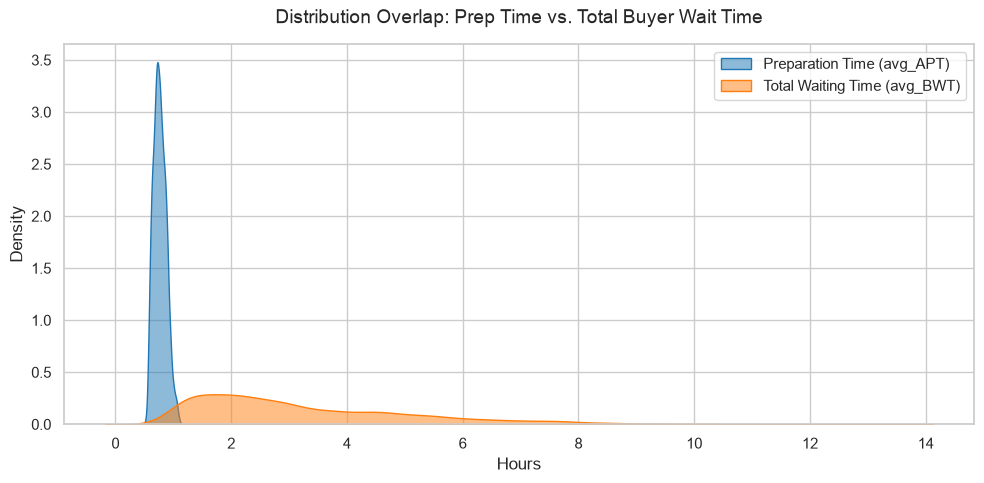

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Plot kernel density estimations for both metrics
sns.kdeplot(data=data, x='avg_APT', fill=True, label='Preparation Time (avg_APT)', color='#1f77b4', alpha=0.5)
sns.kdeplot(data=data, x='avg_BWT', fill=True, label='Total Waiting Time (avg_BWT)', color='#ff7f0e', alpha=0.5)

plt.title('Distribution Overlap: Prep Time vs. Total Buyer Wait Time', fontsize=14, pad=15)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


#### Analysis

Warehouse preparation time is highly consistent and stable under 1 hour. However, total wait time has a severe long tail stretching up to 8 hours, operations must focus heavily on fixing delivery-phase transit bottlenecks

#### Secondary analysis - Actual Carrier Transit Time
Tells us if delivery delays are happening inside the seller's warehouse (high avg_APT) or on the road with the logistics provider (high transit time).

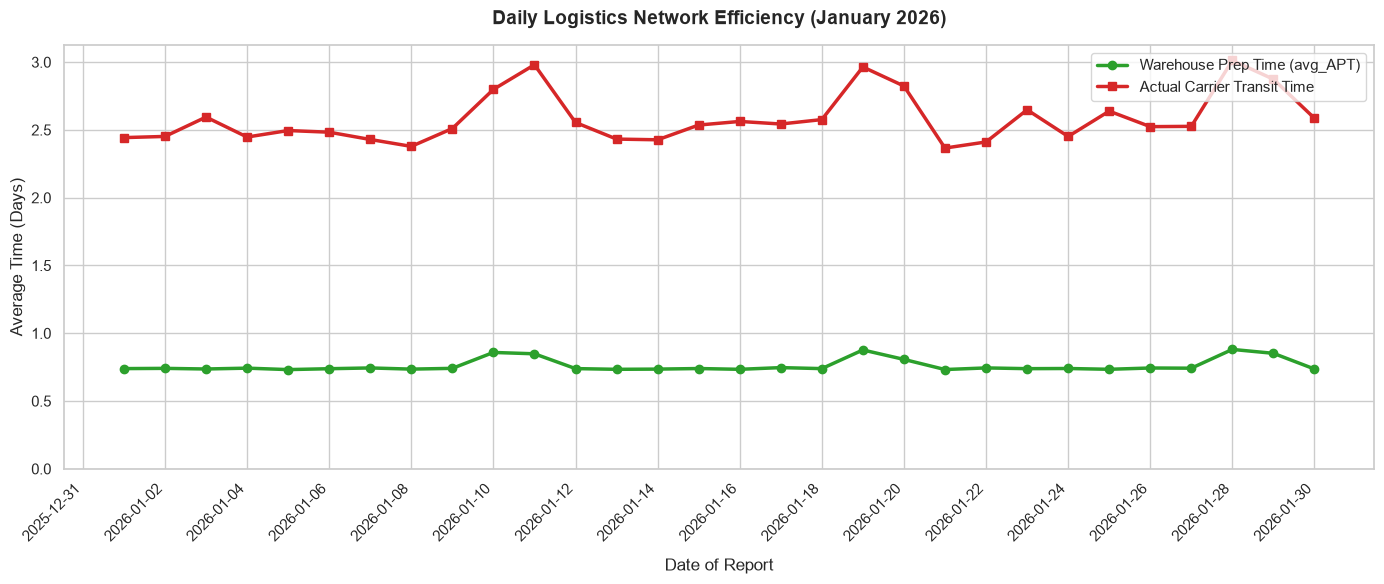

In [26]:
# --- 1. Compute Daily Weighted Averages ---
daily_df = data.groupby('dt').agg(
    total_bwt=('sum_bwt', 'sum'),
    total_apt=('sum_apt', 'sum'),
    total_qty=('parcel_qty', 'sum')
).reset_index()

# Apply the weighted average equations
daily_df['avg_BWT'] = daily_df['total_bwt'] / daily_df['total_qty']
daily_df['avg_APT'] = daily_df['total_apt'] / daily_df['total_qty']

# Isolate transport time from warehouse prep time
daily_df['avg_Transit'] = daily_df['avg_BWT'] - daily_df['avg_APT']

# --- 2. Plotting the Time-Series Chart ---
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

plt.plot(daily_df['dt'], daily_df['avg_APT'], marker='o', linewidth=2.5, 
         label='Warehouse Prep Time (avg_APT)', color='#2ca02c')
plt.plot(daily_df['dt'], daily_df['avg_Transit'], marker='s', linewidth=2.5, 
         label='Actual Carrier Transit Time', color='#d62728')

# --- 3. Crisp Date Formatting for January 2026 ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Label every 2 days
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title('Daily Logistics Network Efficiency (January 2026)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Date of Report', fontsize=12, labelpad=10)
plt.ylabel('Average Time (Days)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=0)  # Starts axis at 0 to see true scale
plt.legend(frameon=True, facecolor='white', loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()



### Analysis

Actual carrier transit times drive all major delays

#### Day-of-Week Operational Volatility Heatmap
Reveals whether system processing speeds down during weekends in January

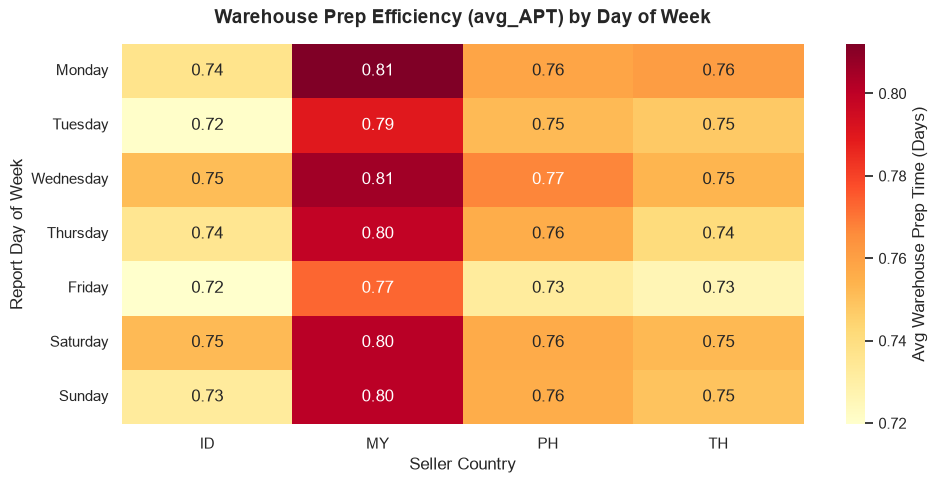

In [27]:
# Extract the day of the week name
data['day_of_week'] = data['dt'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate averages per day per country
dow_df = data.groupby(['day_of_week', 'seller_country']).agg(
    total_qty=('parcel_qty', 'sum'),
    total_apt=('sum_apt', 'sum')
).reset_index()
dow_df['avg_APT'] = dow_df['total_apt'] / dow_df['total_qty']

# Pivot into structured calendar matrix
dow_pivot = dow_df.pivot_table(index='day_of_week', columns='seller_country', values='avg_APT').reindex(weekday_order)

plt.figure(figsize=(10, 5))
sns.heatmap(dow_pivot, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Avg Warehouse Prep Time (Days)'})

plt.title('Warehouse Prep Efficiency (avg_APT) by Day of Week', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Seller Country', fontsize=12)
plt.ylabel('Report Day of Week', fontsize=12)
plt.tight_layout()
plt.show()


#### Analysis

Average preparation time remain highly stable across all days of the week, proving that weekend fulfillment teams are sufficiently staffed and maintaining peak operational efficiency. 

Malaysia (MY) consistently require roughly more processing time (~10%) than regional leaders like Indonesia (ID) regardless of the day.

### Top 10 Slowest Regional Lanes
Identify the geographical bottlenecks that disrupted operations during January.

/var/folders/rh/srs0rrzj02g4nfjm40g6bpg00000gn/T/ipykernel_6750/3242251372.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=slow_lanes, x='avg_BWT', y='route_lane', palette='Reds_r')
/var/folders/rh/srs0rrzj02g4nfjm40g6bpg00000gn/T/ipykernel_6750/3242251372.py:19: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/Users/calvinfrederick/llm-project/llm-project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


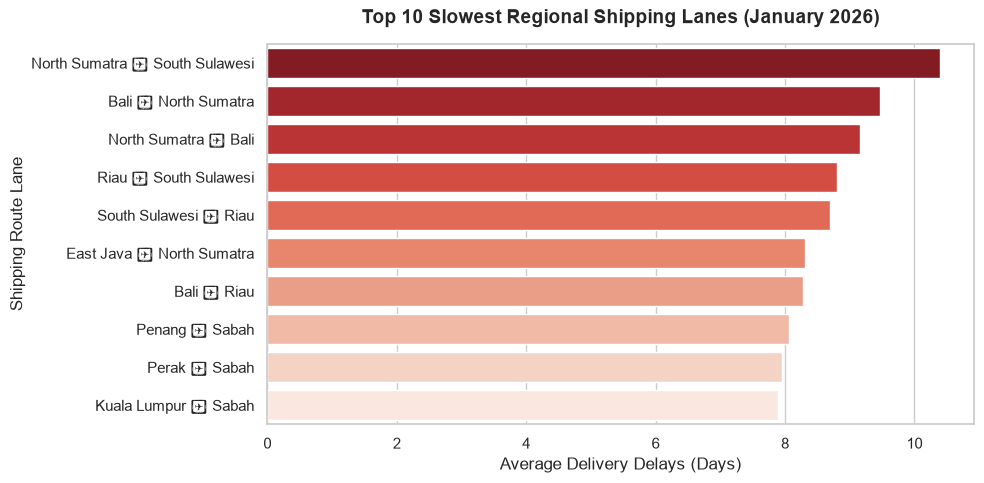

In [28]:
# Aggregate by spatial regional lanes
lane_df = data.groupby(['seller_region', 'buyer_region']).agg(
    total_qty=('parcel_qty', 'sum'),
    total_bwt=('sum_bwt', 'sum')
).reset_index()

lane_df['avg_BWT'] = lane_df['total_bwt'] / lane_df['total_qty']
lane_df['route_lane'] = lane_df['seller_region'] + " ➔ " + lane_df['buyer_region']

# Isolate top 10 bottlenecks (filtering out low-volume anomalies)
slow_lanes = lane_df[lane_df['total_qty'] > 1000].sort_values(by='avg_BWT', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=slow_lanes, x='avg_BWT', y='route_lane', palette='Reds_r')

plt.title('Top 10 Slowest Regional Shipping Lanes (January 2026)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Average Delivery Delays (Days)', fontsize=12)
plt.ylabel('Shipping Route Lane', fontsize=12)
plt.tight_layout()
plt.show()


#### Analysis


Transit lanes connecting North Sumatra, South Sulawesi, and Bali represent severe logistical bottlenecks with average transit delays stretching between 9 to 11 days, meaning dispatchers must prioritize carrier adjustments or alternative air-freight routing for these specific island lanes

### Logistics Provider Performance (Management View)
Highlights which carrier is fastest and which has the most volatile schedules.

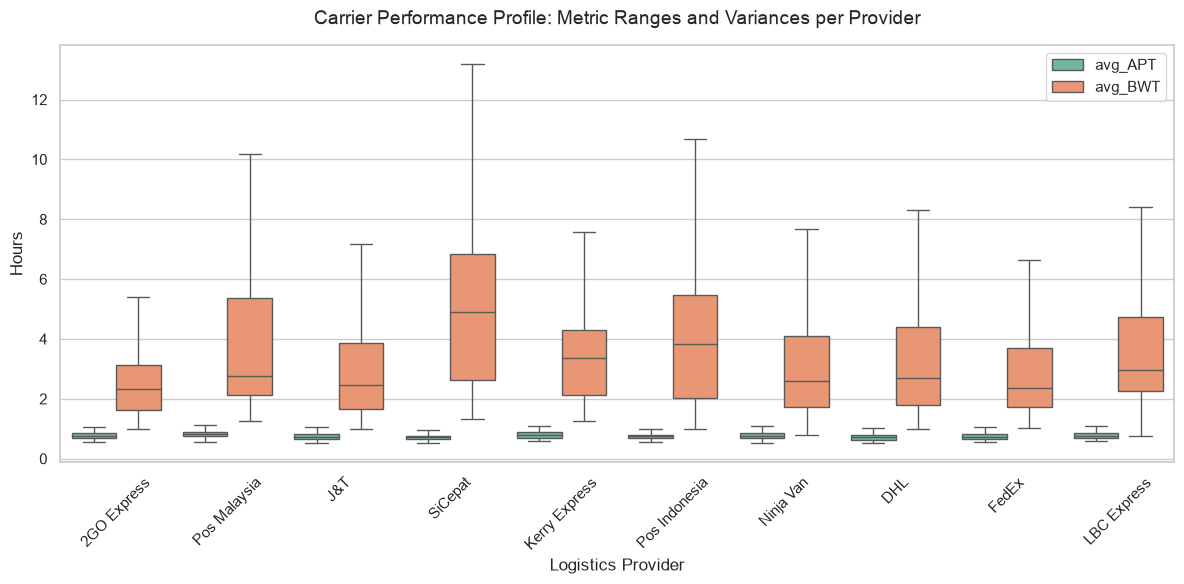

In [29]:
plt.figure(figsize=(12, 6))

# Melt the dataframe to compare metrics side-by-side per provider
melted_df = data.melt(id_vars=['logistics_provider'], value_vars=['avg_APT', 'avg_BWT'], 
                    var_name='Metric', value_name='Hours')

sns.boxplot(data=melted_df, x='logistics_provider', y='Hours', hue='Metric', palette='Set2', fliersize=2)

plt.title('Carrier Performance Profile: Metric Ranges and Variances per Provider', fontsize=14, pad=15)
plt.xlabel('Logistics Provider', fontsize=12)
plt.ylabel('Hours', fontsize=12)
plt.xticks(rotation=45)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


#### Analysis

SiCepat is our lowest-peforming carrier with the highest median wait time of around 5 hours and an extreme delay tail extending up to 13 hours. While warehouse prep time remains uniform under an hour everywhere, transit operations must address the high volatility seens across SiCepat, Pos Indonesia, Pos Malaysia

#### Secondary analysis - Carrier capacity vs Speed performance
Reveals if carriers slow down dramatically when given too many packages, helps us balance shipping allocations

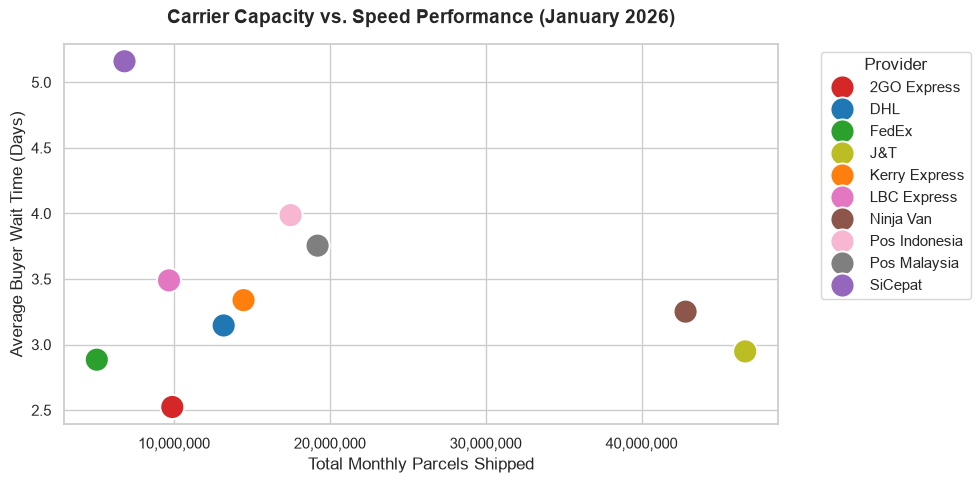

In [30]:

# Aggregate total monthly volume and speed per provider
provider_stress = data.groupby('logistics_provider').agg(
    total_qty=('parcel_qty', 'sum'),
    total_bwt=('sum_bwt', 'sum')
).reset_index()
provider_stress['avg_BWT'] = provider_stress['total_bwt'] / provider_stress['total_qty']

# Define an explicit, highly contrasting color mapping for each carrier
custom_palette = {
    '2GO Express': '#d62728',     # Crimson Red
    'SiCepat': '#9467bd',         # Distinct Purple
    'DHL': '#1f77b4',             # Blue
    'FedEx': '#2ca02c',           # Green
    'J&T': '#bcbd22',             # Olive/Yellow-Green
    'Kerry Express': '#ff7f0e',   # Orange
    'LBC Express': '#e377c2',     # Pink
    'Ninja Van': '#8c564b',       # Brown
    'Pos Indonesia': '#f7b6d2',   # Light Pink
    'Pos Malaysia': '#7f7f7f'     # Slate Grey
}

# Render the updated scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=provider_stress, 
    x='total_qty', 
    y='avg_BWT', 
    hue='logistics_provider', 
    s=300, 
    palette=custom_palette  # Applies your explicit color rules
)

# Format X-axis numbers with clean commas
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.title('Carrier Capacity vs. Speed Performance (January 2026)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Total Monthly Parcels Shipped', fontsize=12)
plt.ylabel('Average Buyer Wait Time (Days)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Provider')
plt.tight_layout()
plt.show()



J&T and Ninja Van manage highest monthly parcel volumes while maintaining low wait times (~3 days) whereas SiCepat exhibit high performance volatility despite handling much smaller volume tiers

### Shipping Volumes by Country (Sales Perspective)
Shows where shipping volume is concentrated in which country

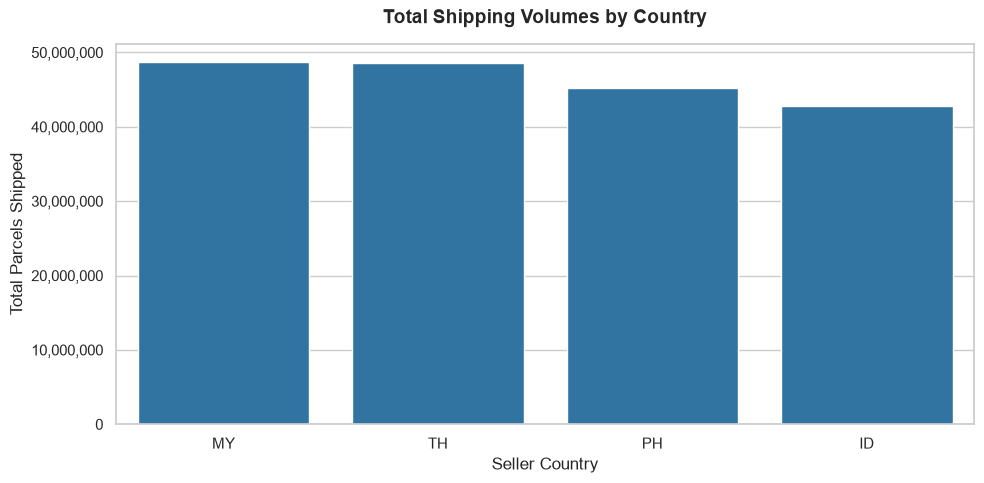

In [31]:
# 1. Aggregate parcel volume by country
country_volumes = data.groupby('seller_country')['parcel_qty'].sum().reset_index()
country_volumes = country_volumes.sort_values(by='parcel_qty', ascending=False)

# 2. Plot the clean bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=country_volumes, x='seller_country', y='parcel_qty', color='#1f77b4')

# 3. Format numbers on the y-axis to look clean (e.g., 1,000,000)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.title('Total Shipping Volumes by Country', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Seller Country', fontsize=12)
plt.ylabel('Total Parcels Shipped', fontsize=12)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

#### Analysis

Parcel volumes are relatively high across the SEA countries, revenue streams are consistent and strong across the countries

## LLM Integration

In [32]:
DEEPSEEK_API_KEY = os.getenv('DEEPSEEK_API_KEY')

## Insights and Findings 

In [47]:
from openai import OpenAI

client = OpenAI(
    api_key=os.environ.get('DEEPSEEK_API_KEY'),
    base_url="https://api.deepseek.com"
)

llm_data_context = f"""
### 1. CARRIER VOLUME & DELAY PROFILE
{data.groupby('logistics_provider').agg(vol=('parcel_qty','sum'), bwt=('avg_BWT','mean'), apt=('avg_APT','mean')).reset_index().round(2).to_markdown(index=False)}

### 2. TOP CORRIDOR BOTTLENECKS
{data.groupby(['seller_region', 'buyer_region']).agg(vol=('parcel_qty','sum'), bwt=('avg_BWT','mean')).reset_index().sort_values(by='bwt', ascending=False).head(5).round(2).to_markdown(index=False)}

### 3. WAREHOUSE REGIONAL BASELINES (APT)
{data.groupby('seller_country').agg(vol=('parcel_qty','sum'), apt=('avg_APT','mean')).reset_index().round(2).to_markdown(index=False)}
"""

def run_automated_eda_interpretation_v4(target_audience):
    """
    Executes deep data interpretation using the native DeepSeek-V4-Pro 
    Thinking and Reasoning configurations from the official documentation.
    """
    persona_prompts = {
        "operational": ("You are a Logistics Field Operations Supervisor. Analyze the tables to isolate immediate courier delays and lane bottlenecks. Deliver concise, action-oriented bullet points in json format."),
        "management": ("You are a Logistics Executive Strategic Advisor. Synthesize the metrics into a high-level summary focusing on regional scaling, market stability, and network risks in json format"),
        "bi_analyst": ("You are a Senior BI Architect. Critically review the data metrics to flag potential logging issues, unrecorded gaps, or uniform sampling issues in json format")
    }
    
    system_role = persona_prompts.get(target_audience.lower(), persona_prompts["operational"])
    
    try:
        response = client.chat.completions.create(
            model="deepseek-v4-flash",
            messages=[
                {"role": "system", "content": f"{system_role}\n\nGround your analysis in these clean markdown metrics:\n{llm_data_context}"},
                {"role": "user", "content": "Analyze the structured data above and output your specific insights."}
            ],
            stream=False,
            reasoning_effort="high", # Enables standard high deep thought intensity
            extra_body={"thinking": {"type": "enabled"}}, # Chain of Thought Reasoning Enabled
            response_format = {
                'type': 'json_object'
            }
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"AI Generation Matrix Blocked: {str(e)}"

In [48]:
print("=" * 60 + "\n[LLM ACTIONABLE REPORT: FIELD OPERATIONS VIEW]\n" + "=" * 60)
print(run_automated_eda_interpretation_v4("operational"))

print("\n" + "=" * 60 + "\n[LLM STRATEGIC BRIEF: MANAGEMENT VIEW]\n" + "=" * 60)
print(run_automated_eda_interpretation_v4("management"))
    
print("\n" + "=" * 60 + "\n[LLM DATA HEALTH ASSUMPTION: BI AUDIT VIEW]\n" + "=" * 60)
print(run_automated_eda_interpretation_v4("bi_analyst"))


[LLM ACTIONABLE REPORT: FIELD OPERATIONS VIEW]
{
  "insights": [
    "Immediate courier delay: SiCepat has highest BWT (5.23) and low volume (6.8M), indicating severe bottleneck. Escalate operational review for SiCepat.",
    "Top lane bottleneck: North Sumatra → South Sulawesi (BWT=9.29) and Bali → North Sumatra (8.81) urgently need capacity rebalancing. Reroute or increase courier allocation on these corridors.",
    "Additional high-delay carriers: Pos Indonesia (BWT=4.04) and Pos Malaysia (3.78) require monitoring and possible resource adjustment.",
    "High-volume carriers J&T (46.7M, BWT=2.9) and Ninja Van (42.8M, BWT=3.08) have moderate delays but should be watched to prevent escalation."
  ]
}

[LLM STRATEGIC BRIEF: MANAGEMENT VIEW]
{
  "regional_scaling": {
    "volume_distribution": "TH has lowest volume but consistent APT; MY highest volume with highest APT (0.8); PH and ID similar APT (~0.74-0.76). Indonesia and Malaysia dominate absolute volume.",
    "scaling_challenges"

### Evaluation Framework